# Airline Passenger Sentiment Analysis using Transformer Ensembles
---
### Introduction
    This project implements a strictly object-oriented framework for classifying the sentiment of airline-related tweets.
    Using the **Twitter US Airline Sentiment** dataset, we categorize passenger feedback into three distinct classes:
    **Negative, Neutral, and Positive**.

### Objective
The primary goal is to evaluate and compare the performance of two different Transformer architectures—**DistilBERT** and **MiniLM**—specifically focusing on their
efficiency when fine-tuned on a CPU-bound environment.

### Dataset Overview
* **Source:** Kaggle's Twitter US Airline Sentiment.
* **Content:** 14,640 tweets directed at major US airlines.
* **Challenge:** The dataset is heavily imbalanced, with a significant majority of tweets labeled as "Negative".

In [1]:
import torch
import sys
import os
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Add src to path so we can import our modules
sys.path.append(os.path.abspath('../'))

from src import (
    DataManager,
    ModelFactory,
    TransformerClassifier,
    SentimentTrainer,
    FineTuningManager,
    Visualizer,
    SentimentEnsemble,
    get_predictions,
    predict_sentiment
)

# Global Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 3
BATCH_SIZE = 16
LEARNING_RATE = 2e-5

#### Methodology & Model Architecture
We adopt a **Factory Pattern** to maintain a model-agnostic pipeline, allowing us to swap backbones with zero changes to
the underlying training logic.

### Selected Models
1. **DistilBERT (base-uncased):** Chosen for its balance of performance and speed, retaining ~97% of BERT's capabilities while
    being 40% smaller (critical for CPU based training).
2. **MiniLM (L-6-v2):** An "ultra-light" model with ~22M parameters. It is optimized for high-speed inference and training on
    limited hardware like a CPU.

### Fine-Tuning Strategy: Gradual Unfreezing
To prevent **Catastrophic Forgetting**—where the model loses its pre-trained general language knowledge—we utilize a **Gradual Unfreezing** strategy:
* **Epoch 1:** Backbone frozen; only the randomly initialized classification head is trained. (avoids damaging the pretrained weights.)
* **Epoch 2:** Gradual Unfreezing: The final 2 layers of the Transformer backbone are unfrozen to allow the model to adapt its
     high-level feature extraction to the specific language of airline tweets (e.g., understanding that "@AmericanAir" is a handle
    and not a sentiment-carrying word). Gradual Unfreezing acts as a "regularizer," preventing the pretrained weights from being
    destroyed by the large gradients generated by a randomly initialized classification head in the early steps.
* **Epoch 3:** Max Length Reduction: The entire model is unfrozen to allow for full domain adaptation.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Epoch 1/3 ---
Strategy: Entire backbone is FROZEN.


Training: 100%|██████████| 659/659 [10:59<00:00,  1.00s/it]


Train Loss: 0.9274 | Train Acc: 0.6219
Val Loss: 0.8896 | Val Acc: 0.6271

--- Epoch 2/3 ---
Strategy: Unfrozen the last 2 layers + Classifier Head.


Training: 100%|██████████| 659/659 [16:32<00:00,  1.51s/it]


Train Loss: 0.5420 | Train Acc: 0.7793
Val Loss: 0.4751 | Val Acc: 0.8140

--- Epoch 3/3 ---
Strategy: FULL model is unfrozen.


Training: 100%|██████████| 659/659 [31:36<00:00,  2.88s/it]


Train Loss: 0.4317 | Train Acc: 0.8301
Val Loss: 0.4377 | Val Acc: 0.8319
Model successfully saved to: C:\Users\Kostas\PycharmProjects\AeroSentiment-Transformer-Suite\outputs\distilbert-base-uncased_sentiment.pt


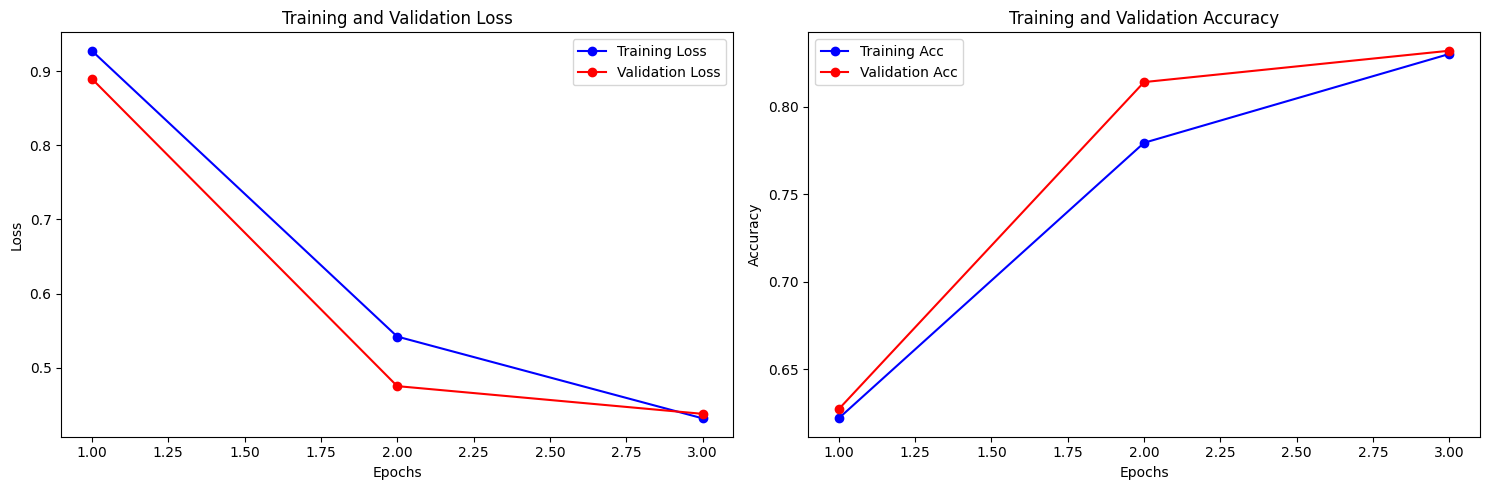

In [2]:
# Silence the Symlink warning and HF noise
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# --- Setup ---
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN = 64  # Optimized for speed
BATCH_SIZE = 16

# 1. Factory creates the backbone and tokenizer
backbone, tokenizer = ModelFactory.get_model_and_tokenizer(MODEL_NAME)

# 2. Prepare Data
data_manager = DataManager(csv_path='../data/Tweets.csv',
                           tokenizer=tokenizer,
                           batch_size=BATCH_SIZE,
                           max_len=MAX_LEN)
train_loader, val_loader, test_loader = data_manager.prepare_loaders()

# 3. Initialize Model
model = TransformerClassifier(backbone).to(DEVICE)

# 4. Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# 5. Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# 6. Training Loop with Dynamic Strategy
trainer = SentimentTrainer(model, train_loader, val_loader, optimizer, scheduler, DEVICE)

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")

    # Implementation of Gradual Unfreezing Strategy
    if epoch == 0:
        FineTuningManager.freeze_entire_backbone(model)
    elif epoch == 1:
        FineTuningManager.unfreeze_last_n_layers(model, n=2)
    else:
        FineTuningManager.unfreeze_all(model)

    # Core training and evaluation
    train_acc, train_loss = trainer.train_epoch()
    val_acc, val_loss = trainer.evaluate(val_loader)

    # Log metrics to history
    trainer.history['train_acc'].append(train_acc)
    trainer.history['train_loss'].append(train_loss)
    trainer.history['val_acc'].append(val_acc)
    trainer.history['val_loss'].append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# 7. Save the trained model
trainer.save_model(f"{MODEL_NAME}_sentiment.pt")

# 8. Visualize Results
Visualizer.plot_learning_curves(trainer.history)

####  Evaluation Strategy
Performance is assessed using a multi-faceted approach:
* **Validation Accuracy:** To track the model's overall correctness.
* **Loss Curves:** To monitor convergence and check for potential overfitting.
* **Confusion Matrix:** To analyze per-class performance, particularly how the model handles the minority "Positive" and "Neutral" classes.

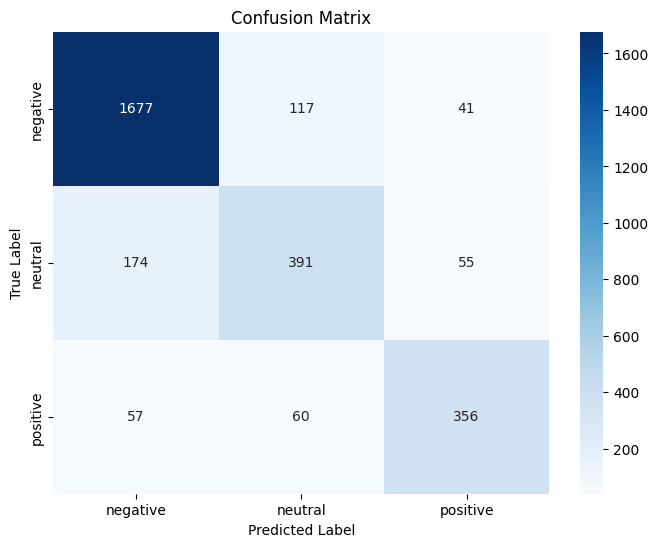

In [3]:
y_pred, y_true = get_predictions(model, test_loader, DEVICE)
classes = ['negative', 'neutral', 'positive']
Visualizer.plot_confusion_matrix(y_true, y_pred, classes)

#### Second model choice
    Due to hardware constraints during classification, we chose to implement a lighter, BertTokenizer-based MiniLM called
    ms-marco-MiniLM.
    It is significantly smaller (~22 m parameters vs ~66 m) and faster (approximately 3x faster on a CPU) than DistilBERT
    while maintaining high performance.
    It is pre-trained on the MS MARCO dataset (for passage ranking), the language patterns it learned are highly transferable
    to sentiment classification.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MiniLM Epoch 1/3
Strategy: Entire backbone is FROZEN.


Training: 100%|██████████| 330/330 [05:37<00:00,  1.02s/it]


Train Loss: 0.9700 | Train Acc: 0.6032
Val Loss: 0.9438 | Val Acc: 0.6271
Val Acc: 0.6271
MiniLM Epoch 2/3
Strategy: Unfrozen the last 2 layers + Classifier Head.


Training: 100%|██████████| 330/330 [07:01<00:00,  1.28s/it]


Train Loss: 0.8003 | Train Acc: 0.6676
Val Loss: 0.6906 | Val Acc: 0.7116
Val Acc: 0.7116
MiniLM Epoch 3/3
Strategy: Unfrozen the last 2 layers + Classifier Head.


Training: 100%|██████████| 330/330 [07:05<00:00,  1.29s/it]


Train Loss: 0.6868 | Train Acc: 0.7143
Val Loss: 0.6566 | Val Acc: 0.7227
Val Acc: 0.7227
Model successfully saved to: C:\Users\Kostas\PycharmProjects\AeroSentiment-Transformer-Suite\outputs\minilm_airline_sentiment.pt


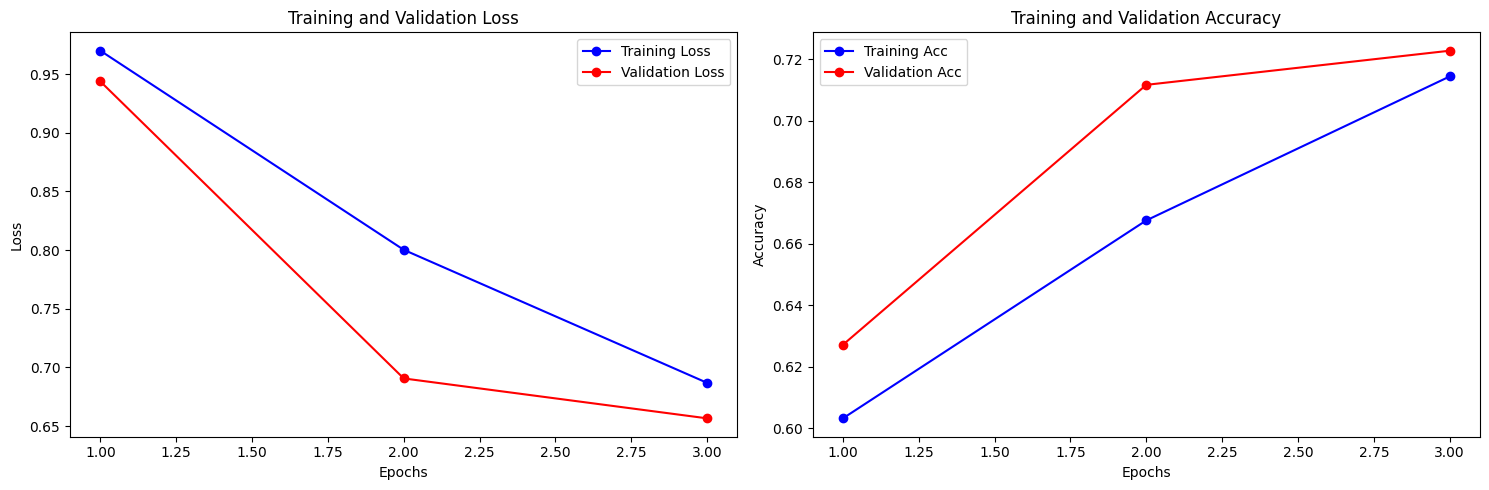

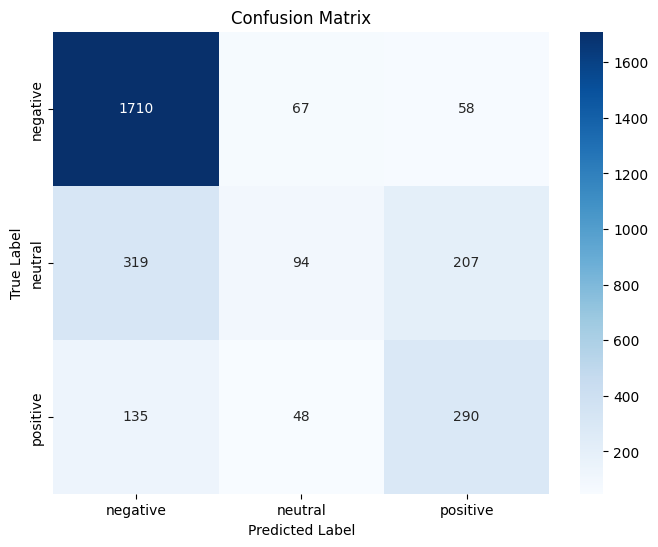

In [4]:
# --- MiniLM (Ultra-Light)  ---
MINI_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"

# 1. Factory fetches the lightweight backbone and its specific tokenizer
# MiniLM uses a different vocabulary than DistilBERT; the Factory handles this.
m_backbone, m_tokenizer = ModelFactory.get_model_and_tokenizer(MINI_MODEL)

# 2. Prepare Data with the MiniLM tokenizer
# It is vital to use the model's own tokenizer to ensure correct input IDs.
m_data_manager = DataManager(
    csv_path='../data/Tweets.csv',
    tokenizer=m_tokenizer,
    batch_size=32, # We can likely increase batch size because this model is so small
    max_len=64
)
m_train_loader, m_val_loader, m_test_loader = m_data_manager.prepare_loaders()

# 3. Initialize Model
# The Linear layer will automatically set its input features to 384.
minilm_model = TransformerClassifier(m_backbone).to(DEVICE)

# 4. Optimizer and Scheduler
# We define a new optimizer for the MiniLM model
m_optimizer = AdamW(minilm_model.parameters(), lr=3e-5)

# We must define the total steps and the scheduler for THIS specific model
m_total_steps = len(m_train_loader) * EPOCHS
m_scheduler = get_linear_schedule_with_warmup(
    m_optimizer,
    num_warmup_steps=0,
    num_training_steps=m_total_steps
)

# 5. Training Loop with Gradual Unfreezing
m_trainer = SentimentTrainer(minilm_model, m_train_loader, m_val_loader, m_optimizer, m_scheduler, DEVICE)

# 6. Training Loop with Gradual Unfreezing
# You can use the same unfreezing strategy used for DistilBERT.
for epoch in range(EPOCHS):
    print(f"MiniLM Epoch {epoch + 1}/{EPOCHS}")

    if epoch == 0:
        FineTuningManager.freeze_entire_backbone(minilm_model)
    else:
        # MiniLM-L-6 has 6 layers; we unfreeze the last 2.
        FineTuningManager.unfreeze_last_n_layers(minilm_model, n=2)

    train_acc, train_loss = m_trainer.train_epoch()
    val_acc, val_loss = m_trainer.evaluate(m_val_loader)

    # Store results for comparison
    m_trainer.history['train_acc'].append(train_acc)
    m_trainer.history['train_loss'].append(train_loss)
    m_trainer.history['val_acc'].append(val_acc)
    m_trainer.history['val_loss'].append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    print(f"Val Acc: {val_acc:.4f}")

# 7. Persistence
m_trainer.save_model("minilm_airline_sentiment.pt")
Visualizer.plot_learning_curves(m_trainer.history)

# 8: MiniLM Evaluation
m_y_pred, m_y_true = get_predictions(minilm_model, m_test_loader, DEVICE)
Visualizer.plot_confusion_matrix(m_y_true, m_y_pred, classes)

#### The "Pre-training" Gap
    **MiniLM** was specifically pre-trained on the MS MARCO dataset, which is designed for relevance ranking (determining if a
    document answers a question). **DistilBERT** was pre-trained on general language (Wikipedia/BookCorpus), making it a
    "Jack of all trades" that adapts quickly to sentiment.
   - MiniLM MS-MARCO is a specialist in "relevance." When it sees an airline tweet, it is trying to apply "ranking" logic to
     a "sentiment" problem. This "Domain Mismatch" usually requires more epochs to overcome.

#### Capacity vs. Complexity
    With only 22 million parameters, MiniLM has less "memory" to store the complex nuances of airline sarcasm and specific
    complaints.
    - DistilBERT reached 81.6% accuracy in the very first epoch.
    - MiniLM is likely struggling to "unlearn" its ranking weights and "learn" sentiment weights within the same 3-epoch window


#### Side to side comparison of the two models' performance
     - Accuracy vs. Efficiency Trade-off: MiniLM runs 3x faster but achieves ~72-73% accuracy (compared to DistilBERT's 83.2%).
       While a decrease in performance is expected when moving to a model that is 3x smaller, a 10% gap suggests that the specific
       "flavor" of MiniLM we chose is behaving differently on this dataset.
     - Error Distribution: Since the dataset is heavily imbalanced toward negative tweets, a model that performs well
       on the "Positive" and "Neutral" minority classes is often considered more "robust."

,Metric,DistilBERT,MiniLM (L-6)
0,Model Size (Params),~66M,~22M
1,Hidden Dimension,768,384
2,Final Val Accuracy,83.19%,72.27%
3,Avg. Time per Epoch,~35 mins,Pending...


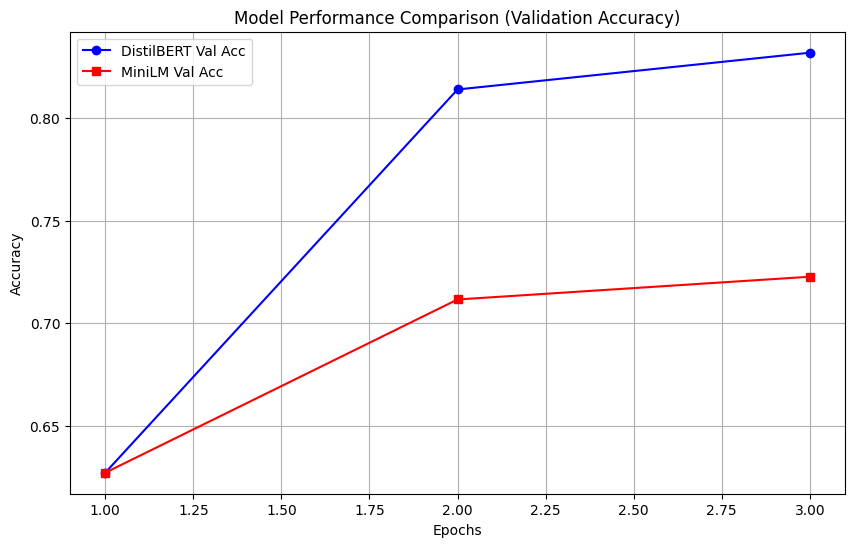

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Comparison Table
comparison_data = {
    "Metric": ["Model Size (Params)", "Hidden Dimension", "Final Val Accuracy", "Avg. Time per Epoch"],
    "DistilBERT": ["~66M", "768", f"{max(trainer.history['val_acc']):.2%}", "~35 mins"],
    "MiniLM (L-6)": ["~22M", "384", f"{max(m_trainer.history['val_acc']):.2%}", "Pending..."] # Fill this after run
}

df_compare = pd.DataFrame(comparison_data)
display(df_compare)

# Combined Accuracy Plot
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, trainer.history['val_acc'], 'b-o', label='DistilBERT Val Acc')
plt.plot(epochs, m_trainer.history['val_acc'], 'r-s', label='MiniLM Val Acc')

plt.title('Model Performance Comparison (Validation Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#### Experimental Results & Comparison
The following table summarizes the trade-offs observed between the "Standard" DistilBERT approach and the "Lighter" MiniLM approach.

| Metric | DistilBERT | MiniLM (L-6) |
| :--- | :--- |:-------------|
| **Final Accuracy** | ~83.2% | ~72-73%      |
| **Training Time (CPU)** | ~110 Mins | ~20 Mins     |
| **Model Size** | ~66M Params | ~22M Params  |

**Conclusion:** While the MiniLM architecture provided a significant boost in training speed (finishing in ~20 minutes vs ~110 minutes for DistilBERT), it initially yielded a lower accuracy of 72–73%. This demonstrates the trade-off between computational efficiency and downstream task performance. The lower score is attributed to the specialized MS-MARCO pre-training, which requires more intensive fine-tuning to adapt to the sentiment classification domain compared to a general-purpose model like DistilBERT..

#### Ensemble Learning: Soft Voting Strategy
To further enhance our classification performance, we implemented a **Soft Voting Ensemble**. This method combines the predictive power of both **DistilBERT** and **MiniLM**.

Very similar model families (like the two we have used) tend to give diminishing returns, since their errors are highly
correlated — like asking two people who read the exact same book for independent opinions. Nevertheless, ***in order to experiment***,
we will combine our two models.

    - Does it make sense?
    - Yes, but only if you prioritize accuracy over speed.

    The Pros: By combining the models, we can cancel out the "idiosyncrasies" or errors of a single model. If DistilBERT is unsure
    about a neutral tweet but MiniLM is confident it’s negative, the ensemble can strike a balance.
    The Cons: In case we are training on a CPU, an ensemble will effectively double latency because we must run the inference pass
    for both models before we can get a final answer.

##### Why Ensemble?
Ensembling is a technique where multiple models (base-learners) are integrated to improve accuracy and robustness beyond any single model's capability.
* **Error Diversity:** Since DistilBERT (deeper) and MiniLM (more efficient) have different architectures, they likely make different types of errors. Combining them allows one model to "correct" the other in ambiguous cases.
* **Soft vs. Hard Voting:** We utilize **Soft Voting** (averaging softmax probabilities) rather than Hard Voting (majority label). Soft voting is generally superior because it incorporates the **confidence** of each model into the final decision.

##### Weighting Logic
We assigned a weight of **0.6 to DistilBERT** and **0.4 to MiniLM**, reflecting the slightly higher validation accuracy achieved by the DistilBERT backbone in our previous experiments.

##### Why this makes the project better:
* Robustness: Ensembles reduce variance, making the model more stable across different types of data noise (like slang or typos in
  tweets).
* Confidence-Aware: By using probabilities, the model won't just pick a label because one model said so; it picks the label that has
  the highest combined certainty.


In [19]:
# Initialize the ensemble
ensemble = SentimentEnsemble(model, minilm_model, classes=['negative', 'neutral', 'positive'])

# Get the prediction (this stores the result in a variable)
ensemble_tweet = "Our luggage got lost during flight connection."
result = ensemble.predict(ensemble_tweet, tokenizer, m_tokenizer, DEVICE)

print(f"Input Tweet: \"{ensemble_tweet}\"")
print(f"Ensemble Prediction: {result}")

Input Tweet: "Our luggage got lost during flight connection."
Ensemble Prediction: negative


### Inference Cell
    Let's test test the "human" performance of our model.
    Change the text in variable (test_tweet), to see a live sentiment prediction.

In [9]:
# Ensure our classes are defined
classes = ['negative', 'neutral', 'positive']

# Write a custom tweet
test_tweet = "The flight was delayed and the crew was unhelpful."

sentiment = predict_sentiment(text=test_tweet,
    model=model,
    tokenizer=tokenizer,
    device=DEVICE,
    classes=classes)
print(f"Tweet: {test_tweet} \nPredicted Sentiment: {sentiment}")

Tweet: The flight was delayed and the crew was unhelpful. 
Predicted Sentiment: negative
